In [117]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.combined_pc_pf_tb import combinedPCPFTb
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.localization.particle_filter import particleFilter
from odometry.estimators.motion_models import GyroEncoderIntegratorMM,OdometryMM
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator

#importing tqdm
from tqdm import tqdm

In [118]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
#initial experiments: "/data/radnav/rad_nav_rotate_experiments/wilk_origin_forward/"

dataset = radnavDS(
    dataset_path=DATASET_PATH + "/WILK_BASEMENT_2",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilk_basement.yaml"
)

found 2063 radar samples
found 2063 lidar samples
found 2063 camera samples
found 2063 imu (orientation only) samples
found 2063imu (full data) samples
found 2063 vehicle velocity samples
loaded map from /data/radnav/maps/wilk_basement.yaml
loaded map free space from /data/radnav/maps/wilk_basement.yaml


In [119]:
motion_model = OdometryMM(
    a1=0.01,
    a2=0.05,
    a3=0.05,
    a4=0.01
)

particle_filter = particleFilter(
    motion_model=motion_model,
    max_particles=10000,
    measurement_model_sigma=0.3,
    measurement_model_z_rand = 0.2,
    measurement_model_z_hit = 0.8
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6,
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 16346 points
loaded map with 16346 points

loaded map with 16346 free points

gt icp estimated heading:8.324316561799002 deg, pose:[0.07888053 0.1294188 ]


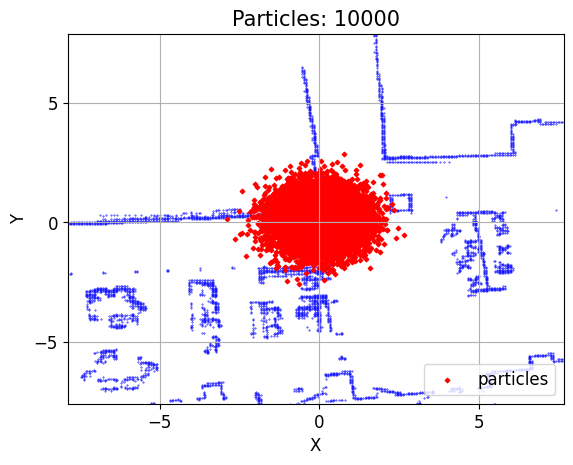

In [120]:
test_bench = combinedPCPFTb(
    localizer=particle_filter,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    self_detection_radius_m=1.0,
    vel_filter_v_thresh = 0.1,
    vel_filter_enabled = True,
    min_static_rejection_radius = 1.5, #was 0.5
    dynamic_cluster_eps = 1.5, #was 3
    dynamic_cluster_min_samples = 15 #was 50
)

start_heading = np.deg2rad(-6.1)
start_pose = np.array([0.03,0.11])

#initializes the lidar ground truth and also initializes
#the particle filter particles
test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    n_particles=10000,
    hdg_range=(-1 * np.pi / 8, np.pi/8), #start with facing forward for now
    show=True
)

In [121]:
#initialize the kalman filter
start_time_s = test_bench.get_dataset_start_time(idx=0)
print("dataset start time: {}s".format(start_time_s))

test_bench.init_motion_model(start_time_s)

dataset start time: 1718811257.6129172s


found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


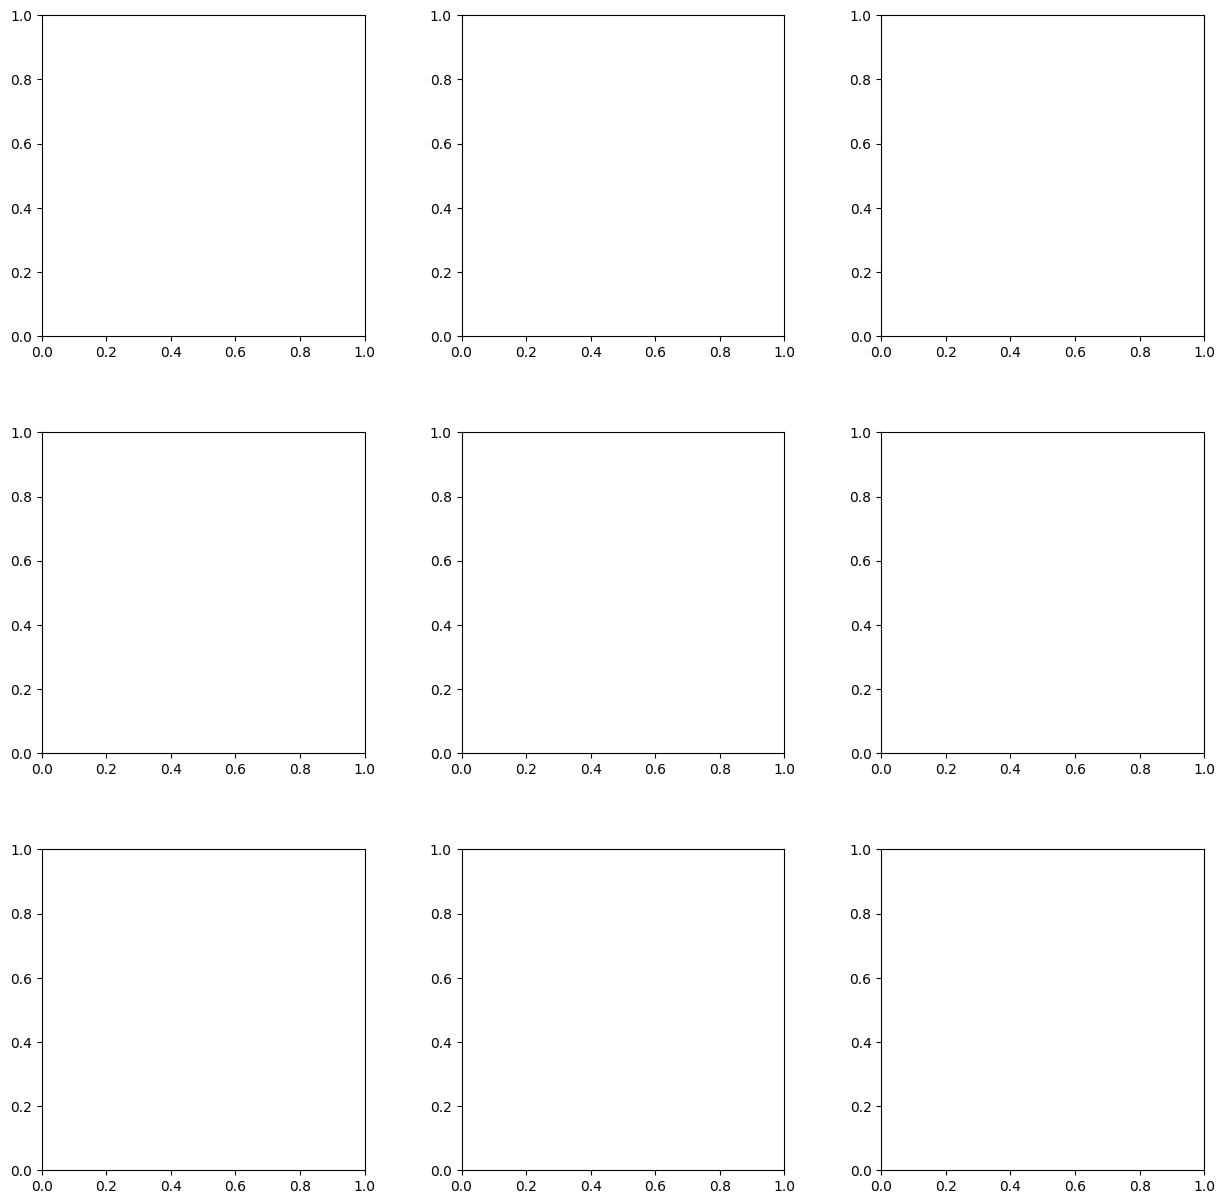

In [122]:
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)

movie_generator.initialize_figure(
    nrows=3,
    ncols=3,
    figsize=(15,15)
)

In [123]:
end_idx = dataset.num_frames #dataset.num_frames

test_bench.run(
    max_frame=end_idx,
    gt_enabled=True,
    movie_generator=None) #=movie_generator)

print(test_bench.gt_localizer.current_pose_m)
print(test_bench.gt_localizer.current_heading_rad)
print(test_bench.localizer.motion_model.x)

 57%|█████▋    | 1174/2063 [02:21<01:25, 10.39it/s]

frame 1172 is bad, (imu: 19,data: 17)


100%|██████████| 2063/2063 [04:31<00:00,  7.59it/s]

[8.28979616 2.05581067]
3.246408268542261
[ 0.89269375 -0.00499253 -0.09479988  0.        ]


In [124]:
movie_generator.save_movie(video_file_name="wilk_pf_trial.mp4",fps=20)

0it [00:00, ?it/s]


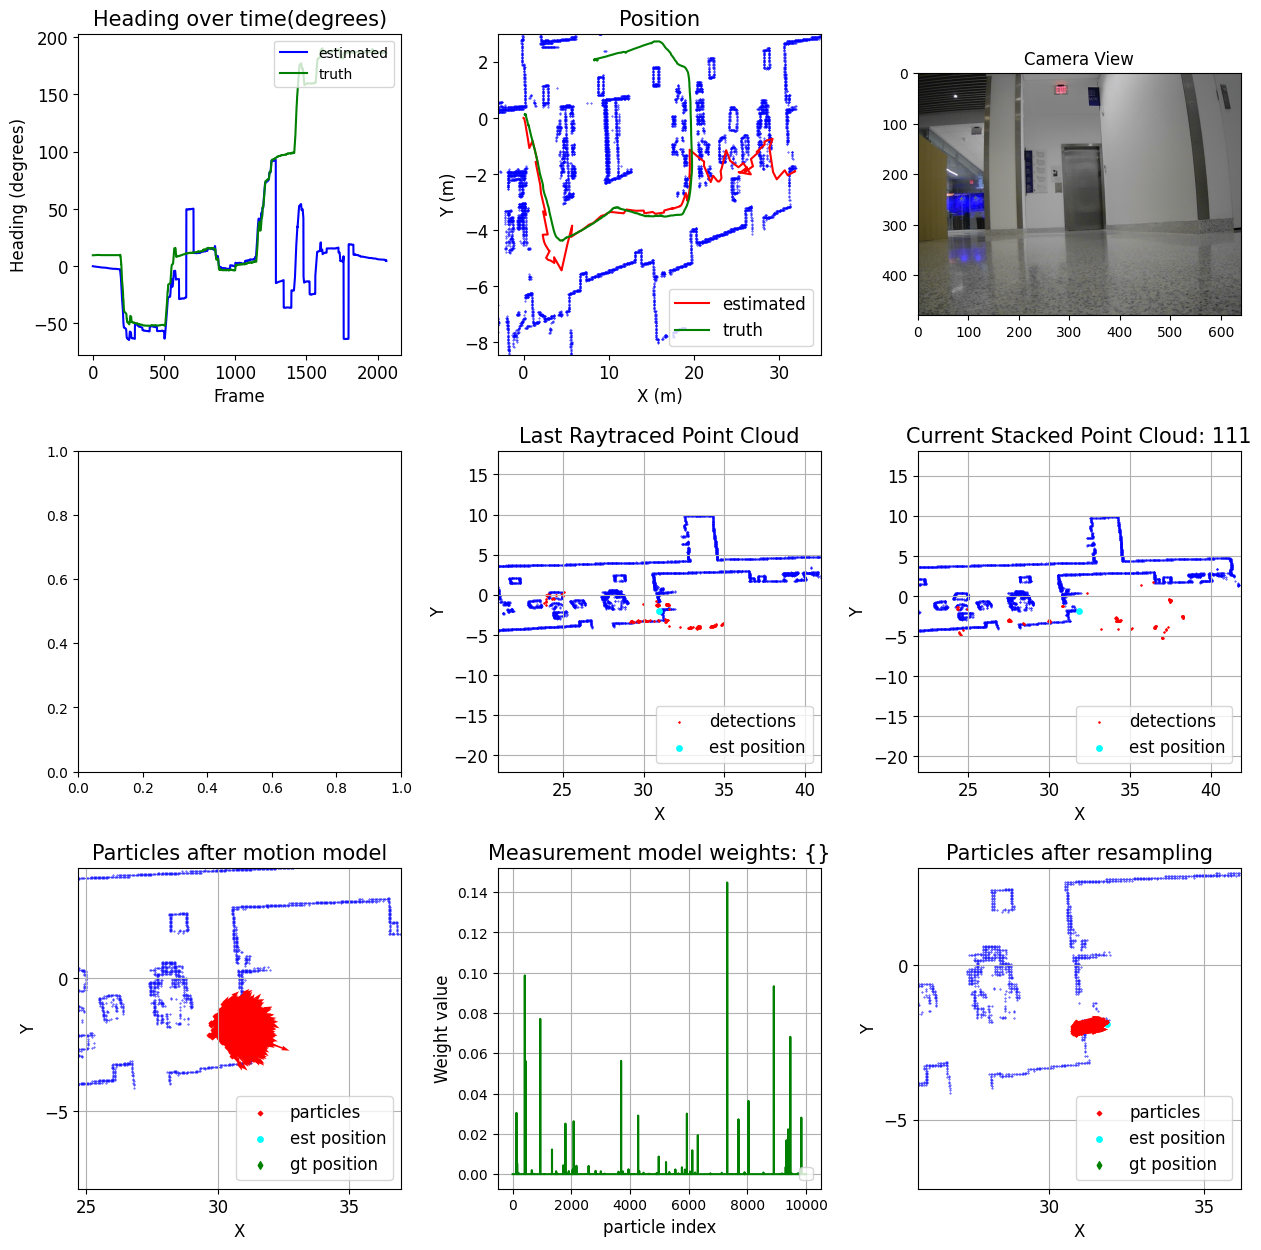

In [137]:
test_bench.plot_compilation(end_idx-1,show=True)

In [138]:
if end_idx == dataset.num_frames:
    test_bench.analyze()

,Metric,Euclidian,x,y,phi
0,Mean,5.800712,-4.759670,1.440373,-1.132869
1,Variance,67.113854,72.874620,3.158363,2.008492
2,Median,1.444985,0.109545,0.310112,-0.207063
3,0.9th percentile,23.131624,22.771341,4.007168,3.130965


## Evaluating Particle Filter History

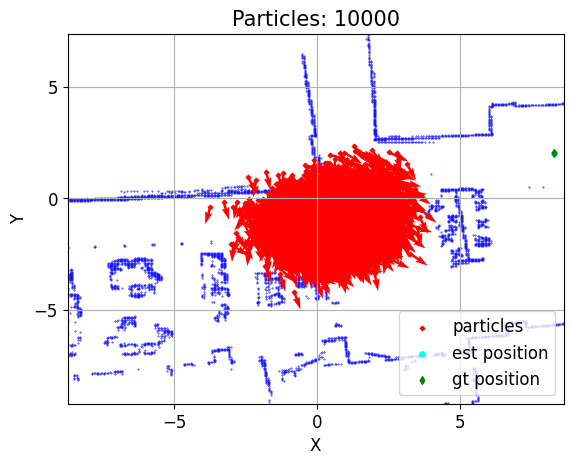

In [139]:
#particles after the motion model
idx = 0
particles = test_bench.history_particles_motion_model[idx]

test_bench.plotter_localization.plot_particles_on_map(
    particles=particles,
    est_pose_m=test_bench.gt_localizer.current_pose_m,
    gt_pose_m=test_bench.gt_localizer.current_pose_m,
    display_arrows=True,
    show=True
)

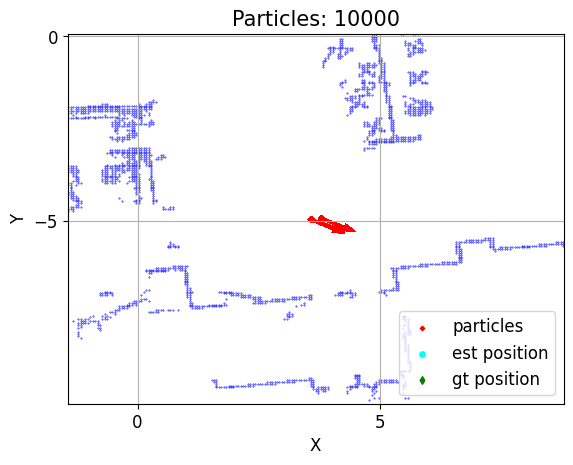

In [140]:
#particles after the measurement model
idx = 6
particles = test_bench.history_particles[idx]

test_bench.plotter_localization.plot_particles_on_map(
    particles=particles,
    est_pose_m=test_bench.gt_localizer.current_pose_m,
    gt_pose_m=test_bench.gt_localizer.current_pose_m,
    display_arrows=True,
    show=True
)

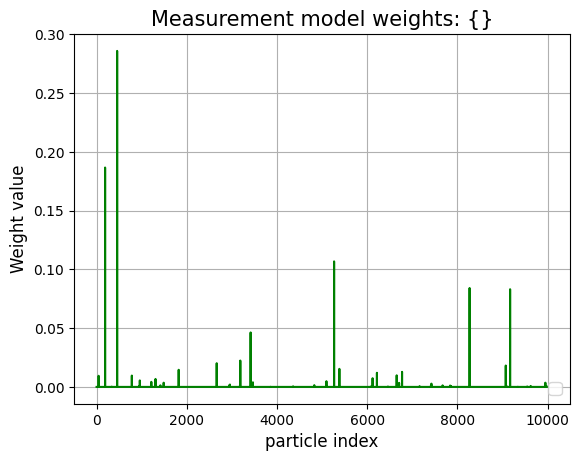

In [141]:
#computed weights
idx = 9
weights = test_bench.history_weights[idx]

test_bench.plotter_localization.plot_weights(
    weights=weights,
    show=True
)

## Evaluating Multipath/Ray Tracing Method

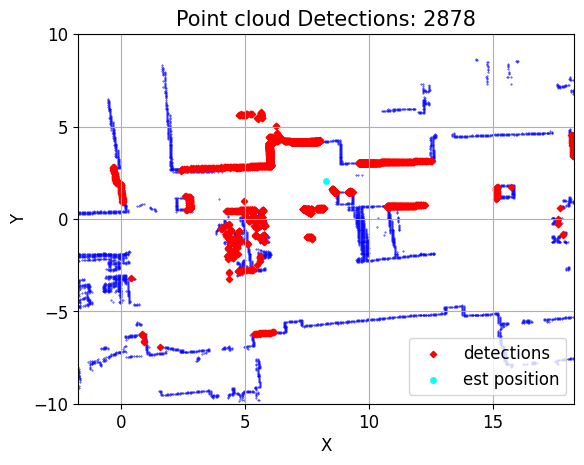

In [142]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

0.0
1.1964473724365234


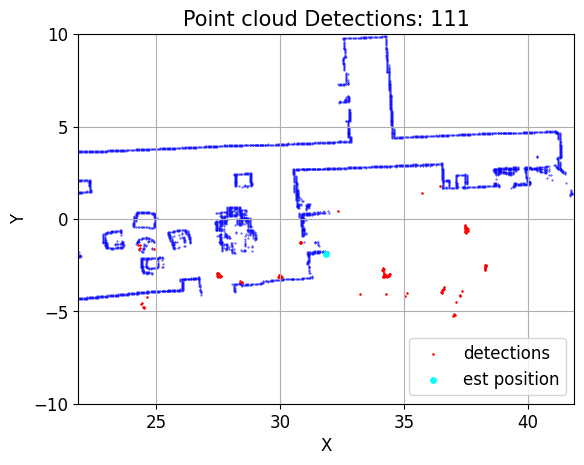

In [143]:
combined_point_cloud = test_bench.point_cloud_stacker.get_points()
print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=combined_point_cloud,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

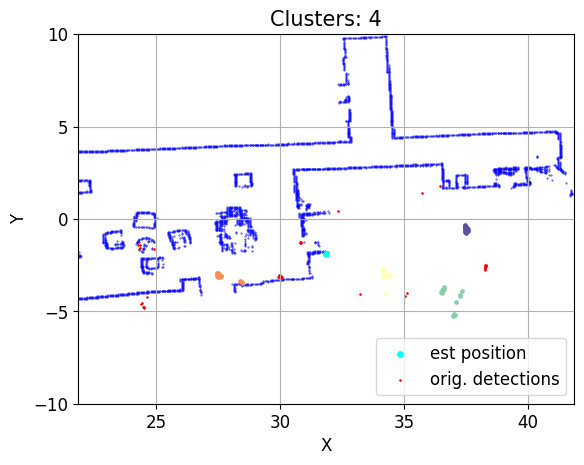

In [144]:
from odometry.point_cloud_processing.multipath import MultiPath
from odometry.supportFns import rotation_functions
from odometry.supportFns import coordinate_systems

stacked_pc_cart = test_bench.point_cloud_stacker.get_points()

multipath = MultiPath(
    clustering_eps=1.0,
    clustering_min_samples=12
)

labels = multipath._cluster_points(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=stacked_pc_cart,
    labels=labels,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    plot_raw_detections=True,
    show=False
)

ax.set_ylim(-10,10)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

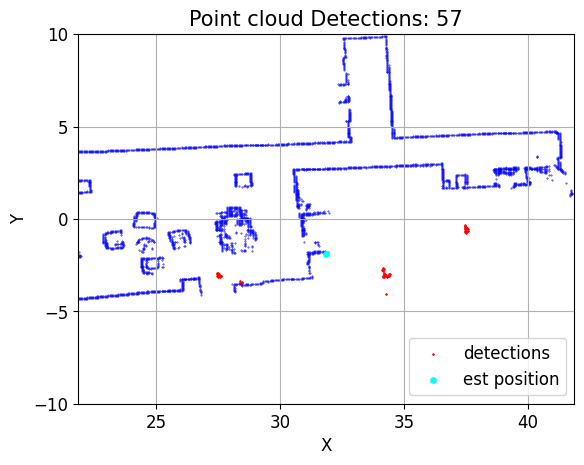

In [145]:
#get the remaining valid points and re-cluster them
valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

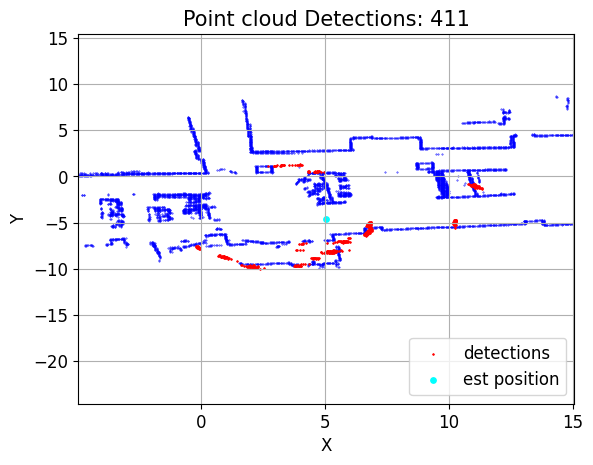

In [146]:
idx = 7
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)

Mean: 0.2671908651522853
Variance: 0.06728412944148857
zero mean var: 0.13867508786231528


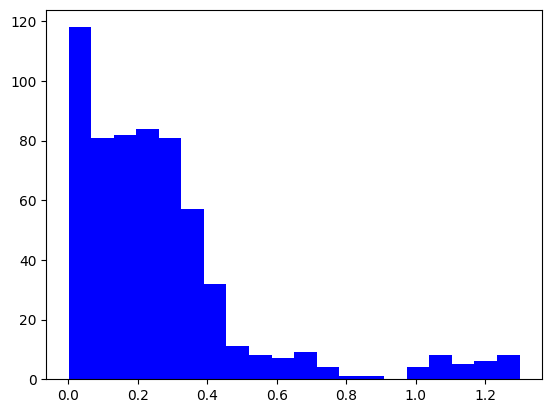

In [147]:
from odometry.supportFns import rotation_functions

#compute the errors
idx = 2
point_cloud = test_bench.history_pc_stacker_point_clouds[idx]
heading_rad = test_bench.history_pc_stacker_heading_rad[idx]
pose_m=test_bench.history_pc_stacker_position_m[idx]

aligned_points = rotation_functions.apply_rot_trans(
    points=point_cloud,
    rot_angle_rad=heading_rad,
    trans=pose_m
)

distances = test_bench.localizer.nbrs.kneighbors(aligned_points)[0]

zero_mean_var = np.sum(
    np.power(distances,2)) / distances.shape[0]

print("Mean: {}\nVariance: {}\nzero mean var: {}".format(
    np.mean(distances),
    np.var(distances),
    zero_mean_var
))
bins = plt.hist(distances, bins=20,color="blue")